In [1]:
import sys
import os
sys.path.append("..")
from sklearn.metrics import mean_squared_error
import copy
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.data_utils.preprocess import scale_features, split_time_series, add_return_features
from src.data_utils.data_loader import load_raw_data
from src.data_utils.windowing import create_windows
from src.models.baselines.lstm_base import LSTMBase
from src.training.train_utils import train_one_epoch, evaluate
from src.utils.config import FEATURE_COLS, RETURN_FEATURES

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
data = load_raw_data()
df = data["AAPL"]
raw_prices = df["Close"].copy()
print(df.head())

               Close      High       Low      Open     Volume
Date                                                         
2000-01-03  0.839281  0.843498  0.762429  0.786328  535796800
2000-01-04  0.768521  0.829440  0.758680  0.811633  512377600
2000-01-05  0.779767  0.828971  0.772270  0.777893  778321600
2000-01-06  0.712287  0.802260  0.712287  0.795700  767972800
2000-01-07  0.746027  0.757274  0.716037  0.723534  460734400


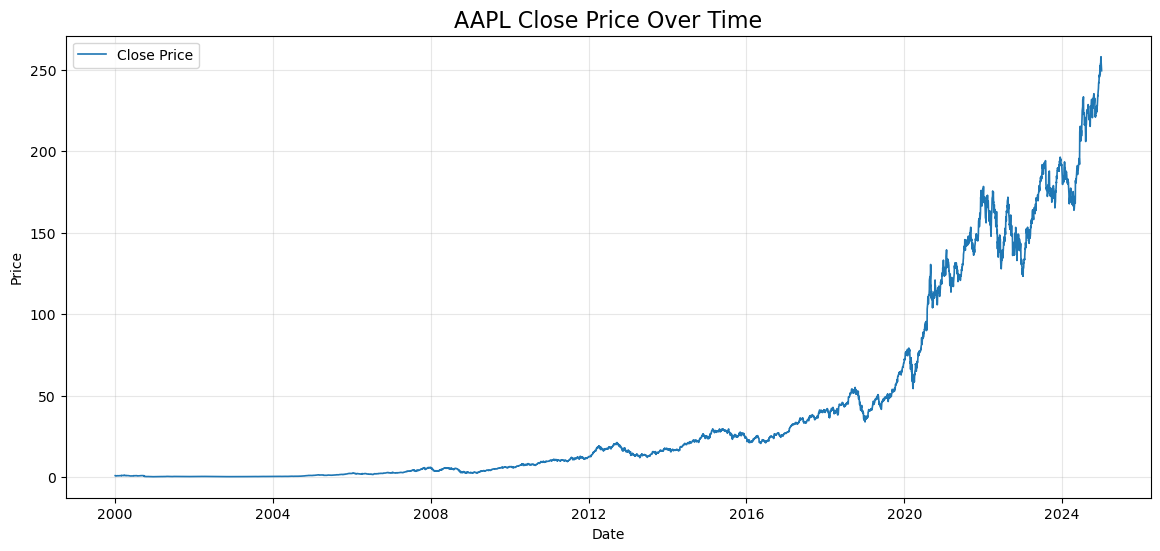

In [3]:

plt.figure(figsize=(14, 6))
plt.plot(df["Close"], label="Close Price", linewidth=1.2)
plt.title(f"AAPL Close Price Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [4]:
df = df[["Close"]]
print(df.head())
train_df, val_df, test_df = split_time_series(df)


               Close
Date                
2000-01-03  0.839281
2000-01-04  0.768521
2000-01-05  0.779767
2000-01-06  0.712287
2000-01-07  0.746027
Checking for missing values...
No missing values found.



In [5]:
print(train_df.head()," | ",train_df.shape)
print(val_df.head(), " | ", val_df.shape)
print(test_df.head(), " | ", test_df.shape)

               Close
Date                
2000-01-03  0.839281
2000-01-04  0.768521
2000-01-05  0.779767
2000-01-06  0.712287
2000-01-07  0.746027  |  (4402, 1)
                Close
Date                 
2017-07-03  33.355171
2017-07-05  33.492317
2017-07-06  33.176193
2017-07-07  33.513218
2017-07-10  33.717773  |  (943, 1)
                 Close
Date                  
2021-04-01  119.913544
2021-04-05  122.740776
2021-04-06  123.043015
2021-04-07  124.690598
2021-04-08  127.088875  |  (944, 1)


In [6]:
X_train, X_val, X_test, scaler = scale_features(
        train_df, val_df, test_df, feature_cols=["Close"] 
    )

print("Feature scaling complete. Scaled features to range [-1, 1].")
print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}\n")
    
# scale the y (Close Price)
y_scaler = MinMaxScaler(feature_range=(-1, 1))
y_train = y_scaler.fit_transform(train_df[["Close"]]).flatten()
y_val = y_scaler.transform(val_df[["Close"]]).flatten()
y_test = y_scaler.transform(test_df[["Close"]]).flatten()

print("Feature scaling complete for target variable 'Close'.")
print(f"y_train shape: {y_train.shape}, y_val shape: {y_val.shape}, y_test shape: {y_test.shape}\n")

Scaling features to range [-1, 1]...

Feature scaling complete. Scaled features to range [-1, 1].
X_train shape: (4402, 1), X_val shape: (943, 1), X_test shape: (944, 1)

Feature scaling complete for target variable 'Close'.
y_train shape: (4402,), y_val shape: (943,), y_test shape: (944,)



In [15]:
#Configuration for the training 
WINDOW_SIZE = 50
BATCH_SIZE =32
EPOCHS = 8
LEARNING_RATE = 1e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}\n")



Using device: cuda



In [16]:
# Windowing 
print("Creating sliding windows...")
print("Creating training windows...")
X_train_win, y_train_win = create_windows(X_train, y_train, WINDOW_SIZE,1)
print(f"X_train_win shape: {X_train_win.shape}, y_train_win shape: {y_train_win.shape}\n")
print("Creating validation windows...") 
X_val_win, y_val_win = create_windows(X_val, y_val, WINDOW_SIZE,1)
print(f"X_val_win shape: {X_val_win.shape}, y_val_win shape: {y_val_win.shape}\n")
print("Creating test windows...")
X_test_win, y_test_win = create_windows(X_test, y_test, WINDOW_SIZE,1)
print(f"X_test_win shape: {X_test_win.shape}, y_test_win shape: {y_test_win.shape}\n")

Creating sliding windows...
Creating training windows...
Creating 4352 windows of size 50...

X_train_win shape: (4352, 50, 1), y_train_win shape: (4352,)

Creating validation windows...
Creating 893 windows of size 50...

X_val_win shape: (893, 50, 1), y_val_win shape: (893,)

Creating test windows...
Creating 894 windows of size 50...

X_test_win shape: (894, 50, 1), y_test_win shape: (894,)



In [17]:
# Convert to tensors 
print("Converting numpy training windows to tensors...")
X_train_t = torch.tensor(X_train_win, dtype=torch.float32)
y_train_t = torch.tensor(y_train_win, dtype=torch.float32)

print("Converting numpy validation windows to tensors...")
X_val_t = torch.tensor(X_val_win, dtype=torch.float32)
y_val_t = torch.tensor(y_val_win, dtype=torch.float32)

print("Converting numpy test windows to tensors...")
X_test_t = torch.tensor(X_test_win, dtype=torch.float32)
y_test_t = torch.tensor(y_test_win, dtype=torch.float32)

# DataLoaders
print("Creating DataLoaders...\n")
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),  
    batch_size=BATCH_SIZE,
    shuffle=False,
)   


Converting numpy training windows to tensors...
Converting numpy validation windows to tensors...
Converting numpy test windows to tensors...
Creating DataLoaders...



In [18]:
# Model, Optimizer, Loss 
model = LSTMBase(num_features=1, hidden_size=32, num_layers=2, dropout=0.5, output_size=1)
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
criterion = nn.MSELoss()

train_losses = []
val_losses = []


In [19]:
# Training loop 
print("Starting BaseLine LSTM training...\n")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    val_loss = evaluate(
        model, val_loader, criterion, DEVICE
    )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )
    
model.eval()
print("Evaluating on test data...")
all_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch) 
        all_preds.append(outputs.cpu().numpy())

Starting BaseLine LSTM training...

Epoch 001 | Train Loss: 0.6353 | Val Loss: 8.9413
Epoch 002 | Train Loss: 0.6202 | Val Loss: 8.9747
Epoch 003 | Train Loss: 0.6025 | Val Loss: 9.0096
Epoch 004 | Train Loss: 0.5844 | Val Loss: 9.0453
Epoch 005 | Train Loss: 0.5649 | Val Loss: 9.0831
Epoch 006 | Train Loss: 0.5418 | Val Loss: 9.1239
Epoch 007 | Train Loss: 0.5152 | Val Loss: 9.1689
Epoch 008 | Train Loss: 0.4823 | Val Loss: 9.2184
Evaluating on test data...
